---
title: Implementando pooling en PyTorch
subject: Aprendizaje Profundo
subtitle: 
short_title: Implementando pooling en PyTorch
authors:
  - name: Jorge Anais
    orcid: 0000-0001-9051-1338
    email: jrganais@gmail.com
license: MIT
---

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jorgeanais/libro_aprendizaje_profundo/blob/main/cap2/030_pooling.ipynb)

**Objetivo**: En este cuadernillo se demostrará visualmente el efecto de las operaciones de pooling sobre imágenes reales.


Basado en Géron (2025) Hands-On Machine Learning with Scikit-Learn and PyTorch.

## Preparativos

In [53]:
import sys
import torch

## Carga de datos

En vez de usar el conjunto de imágenes de muestra de scikit-learn, cargamos dos imágenes propias usando PIL (Pillow). Si estás en Colab, primero sube los archivos `san-joaquin.jpg` y `vina-del_mar_.jpg` usando el panel de archivos.

In [54]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image

# Rutas de las imágenes (ajusta si es necesario)
image_paths = ["san-joaquin.jpg", "vina-del.mar_.jpg"]

# Cargamos y apilamos las imágenes
images_np = np.stack([
    np.array(Image.open(path).convert("RGB"))
    for path in image_paths
])

sample_images = torch.tensor(images_np, dtype=torch.float32) / 255
print(f"Shape de las imágenes cargadas: {sample_images.shape}")

Shape de las imágenes cargadas: torch.Size([2, 563, 1000, 3])


Recortamos cada imagen a un trozo de 140×240 píxeles (alto × ancho) tomado desde el centro, para que el efecto del pooling sea más visible:

In [55]:
crop_h, crop_w = 140, 240

def center_crop(img_tensor, h, w):
    """Recorta el centro de una imagen [H, W, C]."""
    H, W, _ = img_tensor.shape
    top  = (H - h) // 2
    left = (W - w) // 2
    return img_tensor[top:top+h, left:left+w, :]

sample_images = torch.stack([
    center_crop(img, crop_h, crop_w) for img in sample_images
])
print(f"Shape tras el recorte: {sample_images.shape}")

Shape tras el recorte: torch.Size([2, 140, 240, 3])


Permutemos las dimensiones de `[batch, height, width, channels]` a `[batch, channels, height, width]`, tal como espera PyTorch:

In [56]:
sample_images_permuted = sample_images.permute(0, 3, 1, 2)
sample_images_permuted.shape

torch.Size([2, 3, 140, 240])

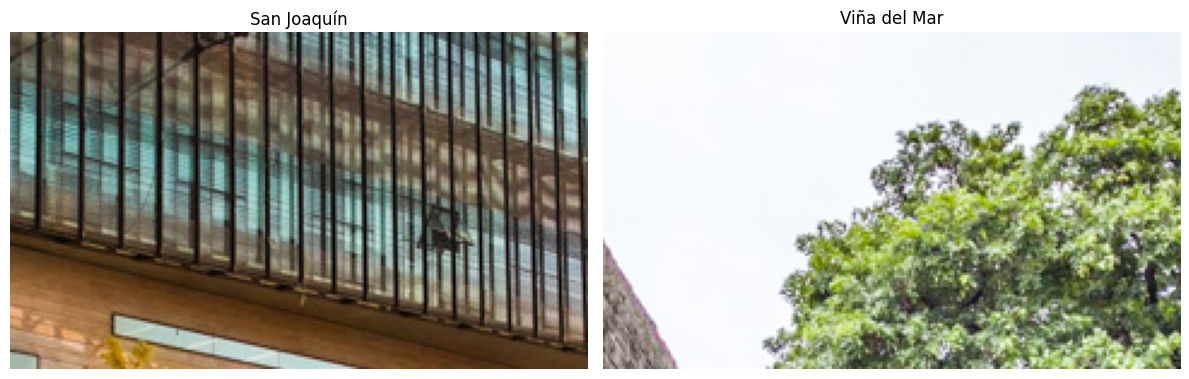

In [57]:
def plot_image(image):
    plt.imshow(image.permute(1, 2, 0))
    plt.axis("off")

plt.figure(figsize=(12, 5))
titles = ["San Joaquín", "Viña del Mar"]
for index, image in enumerate(sample_images_permuted):
    plt.subplot(1, 2, index + 1)
    plot_image(image)
    plt.title(titles[index])
plt.tight_layout()
plt.show()

Ahora reescalemos los valores de los píxeles de 0-255 a 0-1

In [58]:
import torch.nn as nn

torch.manual_seed(42)
conv_layer = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=7)

## Implementación de capas de Pooling

El siguiente código aplica una operación de max pooling sobre al imágen y también de average pooling. En la figura de abajo se observan los resultados.

In [59]:
max_pool = nn.MaxPool2d(kernel_size=2)
output_max = max_pool(sample_images_permuted)

avg_pool = nn.AvgPool2d(kernel_size=2)
output_avg = avg_pool(sample_images_permuted)

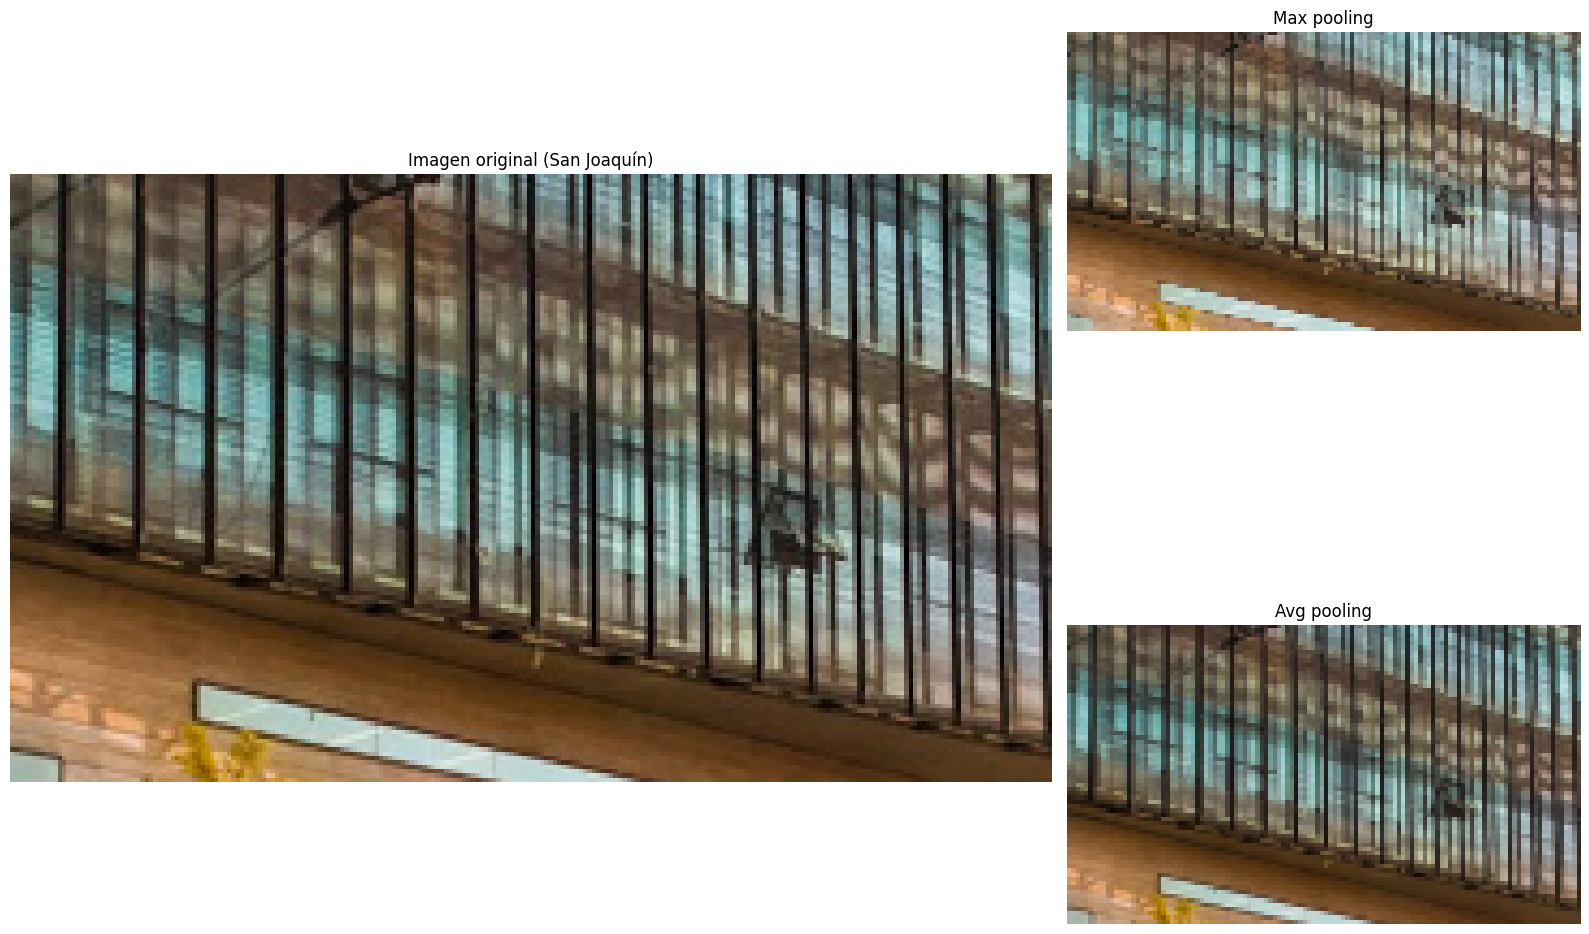

In [60]:
fig = plt.figure(figsize=(16, 12))

ax1 = plt.subplot2grid((2, 3), (0, 0), rowspan=2, colspan=2)
ax1.imshow(sample_images_permuted[0].permute(1, 2, 0))
ax1.axis('off')
ax1.set_title("Imagen original (San Joaquín)")

ax2 = plt.subplot2grid((2, 3), (0, 2))
ax2.imshow(output_max[0].permute(1, 2, 0))
ax2.axis('off')
ax2.set_title("Max pooling")

ax3 = plt.subplot2grid((2, 3), (1, 2))
ax3.imshow(output_avg[0].permute(1, 2, 0))
ax3.axis('off')
ax3.set_title("Avg pooling")

plt.tight_layout()
plt.show()

### Visualización de Pooling para la segunda imagen

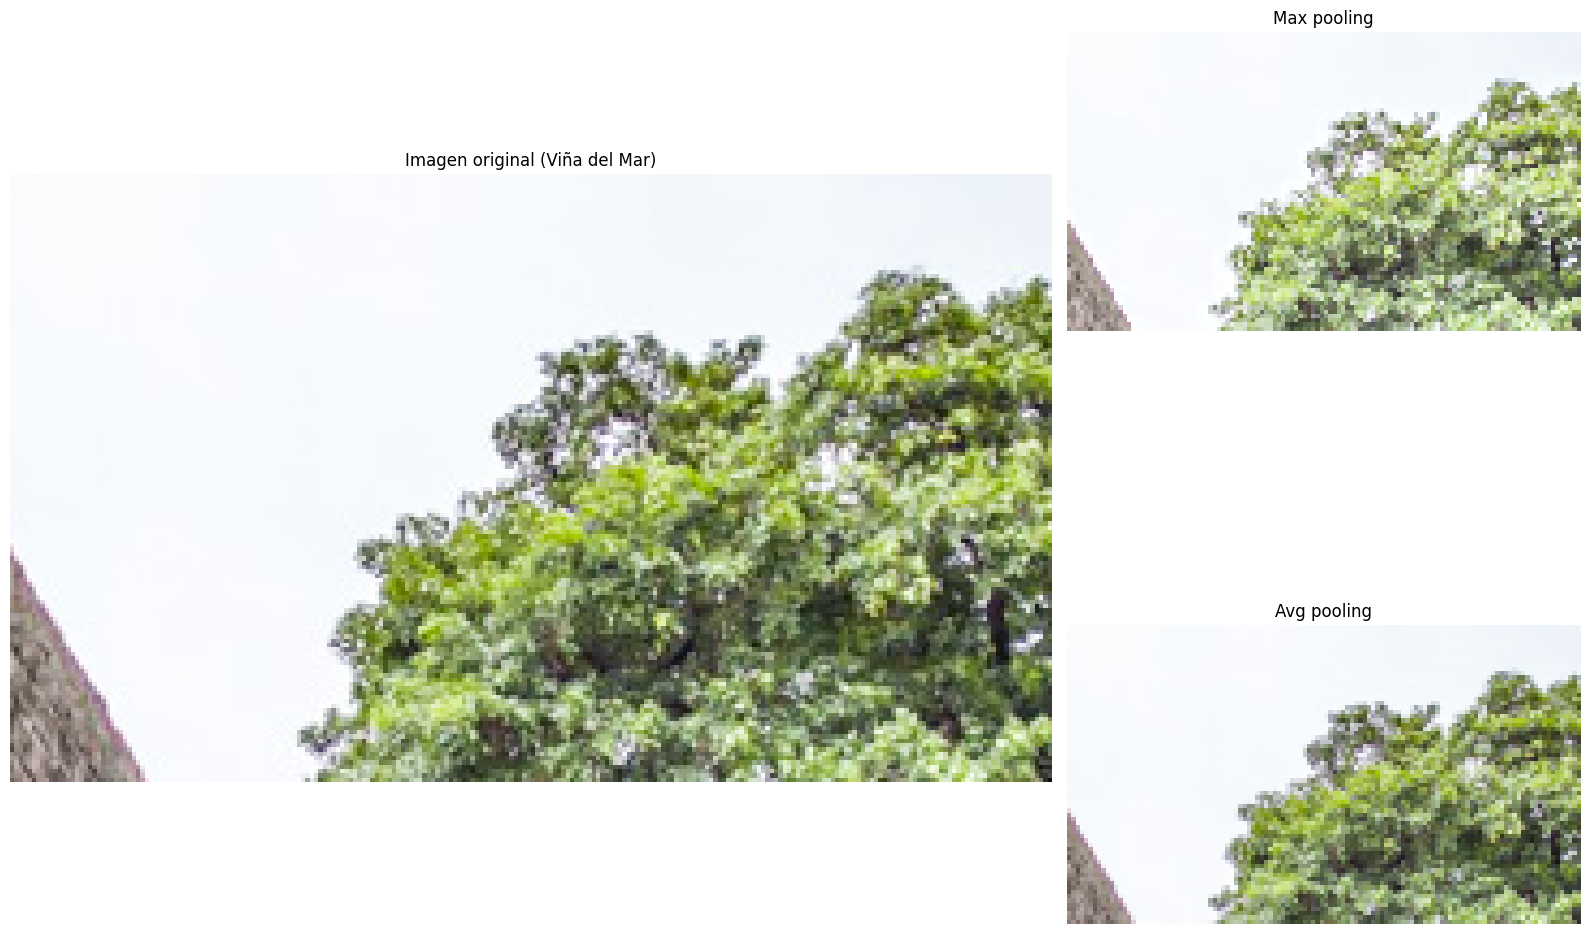

In [62]:
fig = plt.figure(figsize=(16, 12))

ax1 = plt.subplot2grid((2, 3), (0, 0), rowspan=2, colspan=2)
ax1.imshow(sample_images_permuted[1].permute(1, 2, 0))
ax1.axis('off')
ax1.set_title("Imagen original (Viña del Mar)")

ax2 = plt.subplot2grid((2, 3), (0, 2))
ax2.imshow(output_max[1].permute(1, 2, 0))
ax2.axis('off')
ax2.set_title("Max pooling")

ax3 = plt.subplot2grid((2, 3), (1, 2))
ax3.imshow(output_avg[1].permute(1, 2, 0))
ax3.axis('off')
ax3.set_title("Avg pooling")

plt.tight_layout()
plt.show()

### Ejercicio 1.  Preguntas de reflexión

1. Observa la imagen resultante del *max pooling* y compárala con la original. ¿Qué tipo de información visual tiende a conservar esta operación? ¿Por qué crees que preservar ese tipo de información puede ser útil al entrenar una red neuronal convolucional?
<details>
<summary>👉 Clic para mostrar/ocultar respuesta</summary>
<p>
El max pooling selecciona el valor máximo dentro de cada ventana, lo que significa que tiende a conservar las características más destacadas de la imagen: bordes pronunciados, esquinas y zonas de alto contraste. En la práctica, si un filtro convolucional detectó una característica importante en algún punto de la ventana, el max pooling se asegura de que esa activación "sobreviva" aunque la característica no esté exactamente centrada. Esto le da a la red una propiedad de invarianza a pequeñas traslaciones, es decir, la red puede reconocer un patrón aunque aparezca ligeramente desplazado respecto a lo que vio durante el entrenamiento.
</p>
</details>

---

2. El *average pooling* produce una imagen visualmente distinta a la del *max pooling*. ¿En qué situaciones podría ser preferible usar *average pooling* en lugar de *max pooling*? Considera el impacto de cada operación sobre la textura y el contraste de la imagen en tu respuesta.
<details>
<summary>👉 Clic para mostrar/ocultar respuesta</summary>
<p>
El average pooling calcula el promedio de todos los valores de la ventana, lo que produce una representación más suave y distribuida de la región. Esto puede ser preferible en al menos dos situaciones:

1. Cuando interesa capturar el contexto general de una región y no solo sus rasgos más extremos, por ejemplo en tareas donde la textura global importa más que los bordes (clasificación de materiales o superficies).
2. Al final de la red, justo antes de las capas densas, el average pooling global es muy común porque resume la activación media de cada mapa de características completo, reduciendo el riesgo de que un valor atípico domine la representación.

En términos visuales, esto se refleja directamente en las imágenes del notebook: el resultado del average pooling luce más difuminado y uniforme, mientras que el del max pooling conserva mejor los contornos y el contraste de la arquitectura de los edificios DuocUC.
</p>
</details>